### Proyecto de Clasificación de Riesgo Crediticio para la Predicción de Impago (Default), comparando diferentes modelos de clasificación.


El objetivo de este cuaderno es desarrollar, evaluar y comparar múltiples modelos de clasificación (Machine Learning) para predecir si un cliente incurrirá en impago de su crédito (`Default`), a partir de variables socioeconómicas, financieras y demográficas.

**Los datos para modelar:**

```python
le = LabelEncoder()
df['Default'] = le.fit_transform(df['Default'])

y = df['Default']

X = df.drop(columns=['Default', 'Id'])
```

1. **Definición de variables:**

* **Variable Objetivo ($y$):** `Default`: Estado de impago del cliente (Variable binaria a predecir: 0 = No impago, 1 = Impago).

* **Variables Predictoras ($X$):** Categóricas: `Home` (Tipo de vivienda), `Intent` (Motivo del préstamo).

* **Numéricas:** `Age`, `Income`, `Emp_length`, `Amount`, `Rate`, `Percent_income`, `Cred_length`.

**Nota de Preprocesamiento:** Se excluye del conjunto de características ($X$) la columna Id para evitar utilizar un identificador arbitrario que no aporta valor predictivo al modelo.

2. **Tratamiento de Datos Faltantes:**

* **Variables `Emp_length` y `Rate`:** Presentan valores nulos (`NaN`). Se aplica imputación numérica mediante la mediana (`SimpleImputer(strategy='median')`) para evitar la distorsión producida por valores atípicos.

* **Variables Categóricas:** Se aplica imputación basada en el valor más frecuente (SimpleImputer(`strategy='most_frequent'`)) previa a la codificación con One-Hot Encoding (`OneHotEncoder`).

3. **Modelos de Clasificación a Evaluar:**

    a. **Modelos Lineales y Basados en Márgenes:**

      * Regresión Logística (LogisticRegression)

      * Máquinas de Vectores de Soporte (SVC)

    b. **Modelos Basados en Árboles y Ensembles:**

      * Árboles de Decisión (`DecisionTreeClassifier`)

      * Random Forest (`RandomForestClassifier`)

      * Gradient Boosting (`GradientBoostingClassifier`)

      * XGBoost (`XGBClassifier`)

      * LightGBM (`LGBMClassifier`)

4. **Flujo del Proyecto:**

    a. **Carga y Limpieza de Datos:** Carga del archivo `credit_risk.csv` y recodificación de la variable objetivo mediante `LabelEncoder`.

    b. **Análisis Exploratorio de Datos (EDA):** Verificación de distribuciones, identificación de nulos en `Emp_length` y `Rate`, y análisis de correlación entre variables financieras.

    c. **Preprocesamiento:** Construcción de pipelines (`Pipeline` y `ColumnTransformer`) para imputación de nulos, escalamiento estándar (StandardScaler) de variables numéricas y codificación One-Hot de categóricas. División en entrenamiento y prueba (`train_test_split`) estratificada por la variable objetivo.

    d. **Entrenamiento y Ajuste de Modelos:** Ajuste de los algoritmos de clasificación sobre el conjunto de entrenamiento preprocesado.

    e. **Evaluación de Métricas:** Comparativa del rendimiento de los modelos utilizando Accuracy y F1-Score (Macro) para medir la capacidad de discriminación del riesgo de impago.

In [ ]:
import gdown

url = 'https://drive.google.com/drive/folders/1rTijLX8Sq7-7C7dLGiBN1v4Vf8wWWt1H?usp=sharing'
gdown.download_folder(url, quiet=False)

Retrieving folder contents


Processing file 1ih7hc5eQxQShJGVLkX0XEmod9odzl5CT credit_risk.csv
Processing file 1f8uj9UsViESAc5SlPZKSaRxWtVXPUWlf Financials.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1ih7hc5eQxQShJGVLkX0XEmod9odzl5CT
To: /content/Data/credit_risk.csv
100%|██████████| 1.86M/1.86M [00:00<00:00, 66.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1f8uj9UsViESAc5SlPZKSaRxWtVXPUWlf
To: /content/Data/Financials.csv
100%|██████████| 81.9k/81.9k [00:00<00:00, 52.2MB/s]
Download completed


['/content/Data/credit_risk.csv', '/content/Data/Financials.csv']

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Modelos de aprendizaje
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.svm import SVC
from sklearn.decomposition import PCA

# Codificadores de variables categóricas y preprocesamiento
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# Modelos de muestreo
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.model_selection import cross_val_score, KFold

# Optimización de hiperparámetros
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

# Métricas
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_curve, auc
from sklearn import metrics


# Configuración warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('Data/credit_risk.csv')

# Codificamos la variable objetivo
le = LabelEncoder()
df['Default'] = le.fit_transform(df['Default'])

y = df["Default"]
X = df.loc[:, df.columns != 'Default']

cols = X.select_dtypes(include='object').columns
print('Cantidad de datos:', X.shape[0])
print('Cantidad de variables:', X.shape[1])
print('-> Categóricas:', len(cols))
print('-> Numéricas:', X.shape[1]-len(cols), '\n')

print('Etiquetas de variables Categóricas:')
for c in cols:
    print(f'-> {c}: {X[c].unique()}')

print('\n----Cantidad de Nan----')
print(df.isna().sum())
print('\n')

X.head(5)

Cantidad de datos: 32581
Cantidad de variables: 11
-> Categóricas: 2
-> Numéricas: 9 

Etiquetas de variables Categóricas:
-> Home: ['RENT' 'OWN' 'MORTGAGE' 'OTHER']
-> Intent: ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']

----Cantidad de Nan----
Id                   0
Age                  0
Income               0
Home                 0
Emp_length         895
Intent               0
Amount               0
Rate              3116
Status               0
Percent_income       0
Default              0
Cred_length          0
dtype: int64




,Id,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Cred_length
0,0,22,59000,RENT,123.0,PERSONAL,35000,16.02,1,0.59,3
1,1,21,9600,OWN,5.0,EDUCATION,1000,11.14,0,0.10,2
2,2,25,9600,MORTGAGE,1.0,MEDICAL,5500,12.87,1,0.57,3
3,3,23,65500,RENT,4.0,MEDICAL,35000,15.23,1,0.53,2
4,4,24,54400,RENT,8.0,MEDICAL,35000,14.27,1,0.55,4


### Análisis de los datos

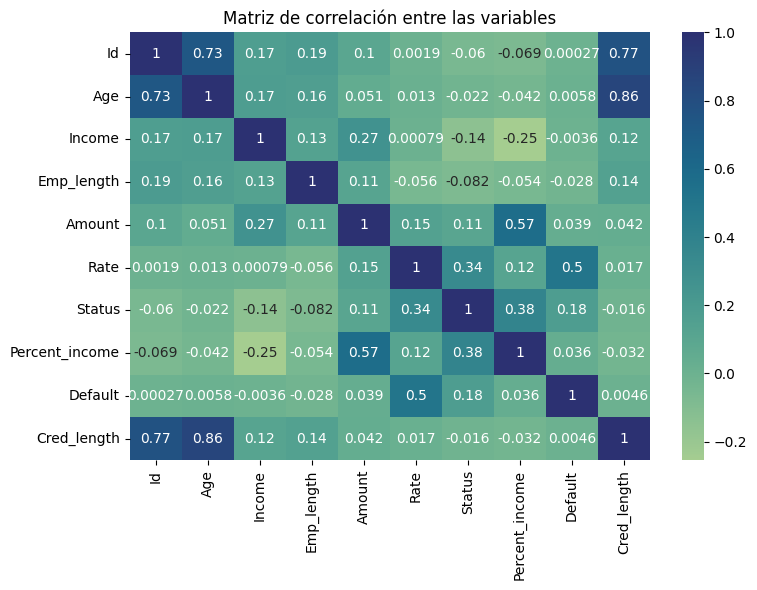

In [ ]:
fig = plt.figure(figsize=(8, 6))
plt.title('Matriz de correlación entre las variables')
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="crest")
fig.tight_layout()

In [ ]:
%%capture
!pip install ydata-profiling

In [ ]:
from ydata_profiling import ProfileReport

# Visualización con ProfileReport
profile = ProfileReport(df, title="Reporte analítico de datos de Financials")
profile.to_file("Financials.html")
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:01<00:00, 11.54it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### Partición y codificación de los datos

In [ ]:
# Del análisis de los datos vemos que la clase Default tiene un gran desbalance de datos
# Esto puede ser un problema para los modelos de clasificación que son sensibles a estos desbalances

# Apliquemos un balanceo a las clases
num_Default0 = df[y==0].shape[0]
num_Default1 = df[y==1].shape[0]

print('Cantidad de datos en la clase 0:', num_Default0)
print('Cantidad de datos en la clase 1:', num_Default1)

# Vemos que hay un gran desbalace de clases y los modelos de clasificación son muy sensibles a esto
# La idea que sean de cantidad similar las clases

df_Default0_ = df[y==0].sample(n=num_Default0-20500, random_state=42)
df_ = pd.concat([df_Default0_, df[y==1]]).reset_index(drop=True)

# Antes de hacer una partición de los datos tenemos que verificar el balance de los datos para las clases objetivo
y_ = df_.Default
X_ = df_.drop('Default', axis=1)

print('\nCantidad de datos en la clase 0 (balanceada):', (y_ == 0).sum())
print('Cantidad de datos en la clase 1 (balanceada):', (y_ == 1).sum())


Cantidad de datos en la clase 0: 26836
Cantidad de datos en la clase 1: 5745

Cantidad de datos en la clase 0 (balanceada): 6336
Cantidad de datos en la clase 1 (balanceada): 5745


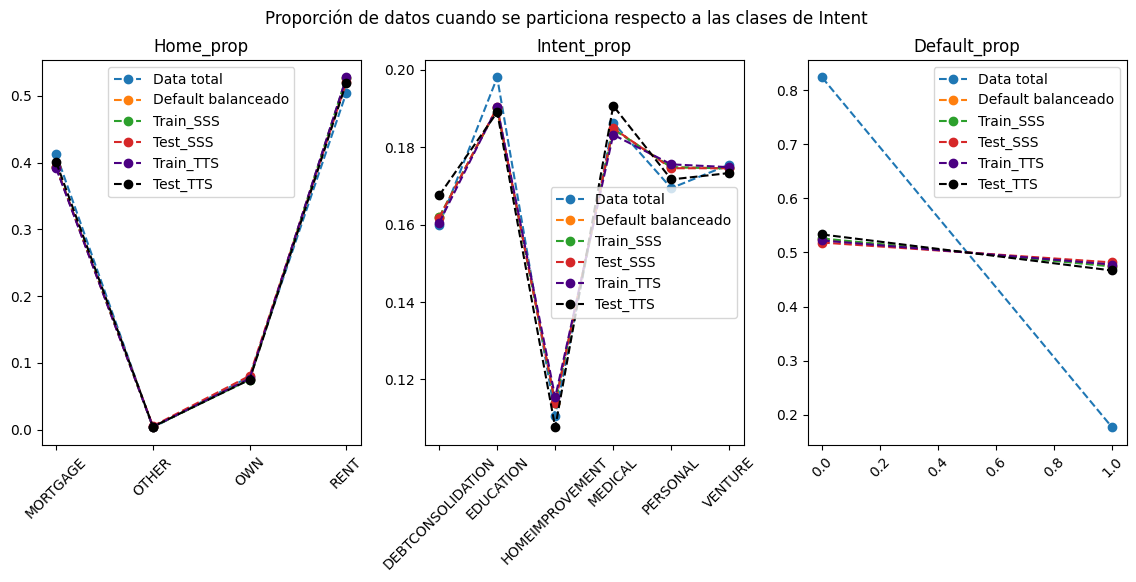

In [ ]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

col_name = 'Intent'
for train_index, test_index in split.split(df_, df_[col_name]):
  df_train, df_test = df_.loc[train_index], df_.loc[test_index]

df_train_TTS, df_test_TTS = train_test_split(df_, test_size=0.2, random_state=42)

# Proporción de datos para las variables categóricas que tienen unas clases específicas
#
fig, axes = plt.subplots(1,3, figsize=(14,5))
fig.suptitle('Proporción de datos cuando se particiona respecto a las clases de %s' %col_name)

cat_features = ['Home', 'Intent', 'Default']
for i in range(3):
    axes[i].set_title(f'{cat_features[i]}_prop')
    axes[i].plot(df.groupby(cat_features[i]).size()/len(df), 'o--', label='Data total')
    axes[i].plot(df_.groupby(cat_features[i]).size()/len(df_), 'o--', label='Default balanceado')
    axes[i].plot(df_train.groupby(cat_features[i]).size()/len(df_train), 'o--', label='Train_SSS')
    axes[i].plot(df_test.groupby(cat_features[i]).size()/len(df_test), 'o--', label='Test_SSS')
    axes[i].plot(df_train_TTS.groupby(cat_features[i]).size()/len(df_train_TTS), 'o--', c='indigo', label='Train_TTS')
    axes[i].plot(df_test_TTS.groupby(cat_features[i]).size()/len(df_test_TTS), 'o--', c='black', label='Test_TTS')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend()

Vemos que cuando se balancea el DataFrame respecto a un balance de las clases de ```Default```, se mantiene la proporción de datos para las diferentes clases de las demás variables categóricas. Además, se observa que se obtiene una mejor partición de los datos usando un modelo estratificado aleatorio ```StratifiedShuffleSplit()```

In [ ]:
# Construcción de un pipeline para los atributos numéricos
'''
  Se utiliza el escalador MixMaxScaler basado en la media pues las distribuciones de cada
  variable es estable, con comportamiento aproximadamente gaussiano y no tienen bastantes
  valores atípicos.
'''
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="mean")),
    ('scaler', MinMaxScaler()),
])

In [ ]:
# Transormador para codificar únicamente las columnas categóricas y devolver un DataFrame
#
class CustomOneHotEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self._oh = OneHotEncoder(sparse_output=False)
        self._columns = None

    def fit(self, X, y=None):
        X_cat = X.select_dtypes(include=['object'])
        self._columns = pd.get_dummies(X_cat).columns
        self._oh.fit(X_cat)
        return self

    def transform(self, X, y=None):
        X_copy = X.copy()
        X_cat = X_copy.select_dtypes(include=['object'])
        X_cat_oh = self._oh.transform(X_cat)
        X_cat_oh = pd.DataFrame(X_cat_oh,
                                columns=self._columns,
                                index=X_copy.index)
        X_copy.drop(list(X_cat), axis=1, inplace=True)
        return X_copy.join(X_cat_oh)

In [ ]:
# Transofrmador que prepara todo el conjunto de datos llamando pipelines y transformadores personalizados
#
class DataFramePreparer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self._full_pipeline = None
        self._columns = None

    def fit(self, X, y=None):
        num_attribs = list(X.select_dtypes(exclude=['object']))
        cat_attribs = list(X.select_dtypes(include=['object']))
        self._full_pipeline = ColumnTransformer([
                ("num", num_pipeline, num_attribs),
                ("cat", CustomOneHotEncoder(), cat_attribs),
        ])
        self._full_pipeline.fit(X)
        self._columns = pd.get_dummies(X).columns
        return self

    def transform(self, X, y=None):
        X_copy = X.copy()
        X_prep = self._full_pipeline.transform(X_copy)
        return pd.DataFrame(X_prep,
                            columns=self._columns,
                            index=X_copy.index)

In [ ]:
transf = DataFramePreparer()
transf.fit(X_)
X_scaled = transf.transform(X_)

# Partición de los datos con los índices encontrados anteriormente
X_train, y_train = X_scaled.loc[train_index], y_.loc[train_index]     # Entrenamiento (80%)
X_test, y_test = X_scaled.loc[test_index], y_.loc[test_index]

X_train.head(5)

,Id,Age,Income,Emp_length,Amount,Rate,Status,Percent_income,Cred_length,Home_MORTGAGE,Home_OTHER,Home_OWN,Home_RENT,Intent_DEBTCONSOLIDATION,Intent_EDUCATION,Intent_HOMEIMPROVEMENT,Intent_MEDICAL,Intent_PERSONAL,Intent_VENTURE
12079,0.999693,0.754717,0.022108,0.040650,0.333333,0.470225,0.0,0.333333,0.678571,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
11242,0.854902,0.150943,0.139504,0.097561,0.507246,0.958427,1.0,0.083333,0.250000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1169,0.147953,0.094340,0.015719,0.048780,0.275362,0.383962,1.0,0.388889,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4687,0.989502,0.301887,0.029964,0.008130,0.188406,0.341011,0.0,0.152778,0.464286,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6985,0.099515,0.075472,0.015719,0.065041,0.086957,0.429213,0.0,0.138889,0.035714,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### Modelo de regresión logística

-> LogisticRegression: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
-> Mejor score f1 (precisión y recall): 0.8145334470279803
MSE: 0.17997517583781547
MAE: 0.17997517583781547
F1 score: 0.8160676532769556
Accuracy: 0.8200248241621845 



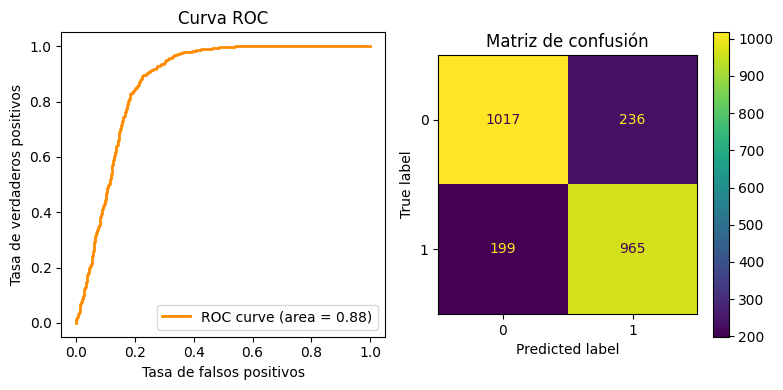

In [ ]:
model_LG = LogisticRegression(random_state=42)

param_grid_LG = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': [0.1, 1, 10],     # Inversa de la fuerza de regularización
    'solver': ['saga', 'lbfgs', 'liblinear']
}

'''
  Métricas de clases desbalanceadas:
  * accuracy: Cuando las clases están balanceadas y quieres maximizar la tasa global de aciertos.
  * roc_auc: Muy usada para clasificación binaria, mide la capacidad de discriminar entre clases.
  * f1: Para balancear precisión y recall, especialmente en clases desbalanceadas.
  * average_precision: Equivalente al área bajo curva Precision-Recall. Muy útil en problemas con fuerte desbalance de clases.
'''

grid_LG = GridSearchCV(model_LG, param_grid_LG, cv=5, scoring='f1', n_jobs=-1)
grid_LG.fit(X_train, y_train)

print("-> LogisticRegression:", grid_LG.best_params_)
print("-> Mejor score f1 (precisión y recall):", grid_LG.best_score_)

best_LG = grid_LG.best_estimator_

y_pred_LG = best_LG.predict(X_test)

mse_LG = mean_squared_error(y_test, y_pred_LG)
mae_LG = mean_absolute_error(y_test, y_pred_LG)
f1_LG = f1_score(y_test, y_pred_LG)     # precisión y recall
accuracy_LG = accuracy_score(y_test, y_pred_LG)

print(f'MSE: {mse_LG}')
print(f'MAE: {mae_LG}')
print(f'F1 score: {f1_LG}')
print("Accuracy:", accuracy_score(y_test, y_pred_LG), '\n')

cm_LG = confusion_matrix(y_test, y_pred_LG)

# Gráficos de métricas
fig, axes = plt.subplots(1, 2, figsize=(8,4))

axes[0].set_title("Curva ROC")
fpr, tpr, thresholds = roc_curve(y_test, best_LG.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
#roc = RocCurveDisplay.from_estimator(best_LG, X_test, y_test)
#roc.plot(ax=axes[0])
axes[0].set_xlabel('Tasa de falsos positivos')
axes[0].set_ylabel('Tasa de verdaderos positivos')
axes[0].legend()
axes[0].grid(False)

axes[1].set_title("Matriz de confusión")
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_LG)
disp.plot(ax=axes[1])
axes[1].grid(False)

fig.tight_layout()

### Modelo de Árboles de decisión

-> LogisticRegression: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
-> Mejor score f1 (precisión y recall): 0.8467284029546154
MSE: 0.15887463798096815
MAE: 0.15887463798096815
F1 score: 0.8442822384428224
Accuracy: 0.8411253620190319 



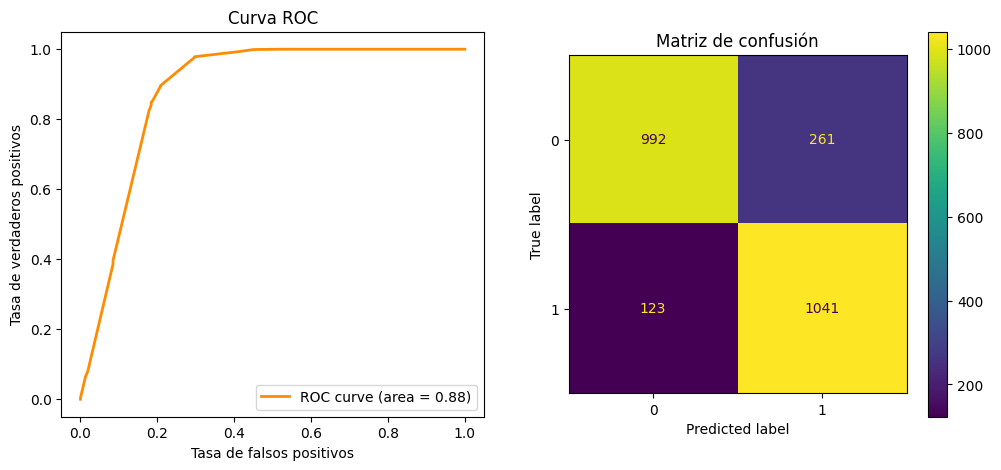

In [ ]:
# class_weight='balanced' -> Pesos asociados a clases en la forma: utiliza los valores de y para ajustar automáticamente los pesos inversamente proporcionales a las frecuencias de clase
# 'criterion' -> Función para medir la calidad del split
# 'max_features' -> Número máximo de características para buscar split: None=todas
model_DTC = DecisionTreeClassifier(random_state=42, class_weight='balanced', criterion='gini', max_features=None)

param_grid_DTC = {
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],      # Mínimo número de muestras para dividir un nodo
    'min_samples_leaf': [1, 2, 4],        # Mínimo número de muestras en una hoja
}

grid_DTC = GridSearchCV(model_DTC, param_grid_DTC, cv=5, scoring='f1', n_jobs=-1)
grid_DTC.fit(X_train, y_train)

print("-> LogisticRegression:", grid_DTC.best_params_)
print("-> Mejor score f1 (precisión y recall):", grid_DTC.best_score_)

best_DTC = grid_DTC.best_estimator_

y_pred_DTC = best_DTC.predict(X_test)

mse_DTC = mean_squared_error(y_test, y_pred_DTC)
mae_DTC = mean_absolute_error(y_test, y_pred_DTC)
f1_DTC = f1_score(y_test, y_pred_DTC)     # precisión y recall
accuracy_DTC = accuracy_score(y_test, y_pred_DTC)

print(f'MSE: {mse_DTC}')
print(f'MAE: {mae_DTC}')
print(f'F1 score: {f1_DTC}')
print("Accuracy:", accuracy_score(y_test, y_pred_DTC), '\n')

cm_DTC = confusion_matrix(y_test, y_pred_DTC)

# Gráficos de métricas
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("Curva ROC")
fpr, tpr, thresholds = roc_curve(y_test, best_DTC.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
axes[0].set_xlabel('Tasa de falsos positivos')
axes[0].set_ylabel('Tasa de verdaderos positivos')
axes[0].legend()
axes[0].grid(False)

axes[1].set_title("Matriz de confusión")
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_DTC)
disp.plot(ax=axes[1])
axes[1].grid(False)

plt.show()

### Modelo de bosques aleatorios

-> RandomForestClassifier: {'max_depth': 20, 'n_estimators': 300}
-> Mejor score f1 (precisión y recall): 0.8546708551910503
MSE: 0.15018618121638394
MAE: 0.15018618121638394
F1 score: 0.8556660039761431
Accuracy: 0.8498138187836161 



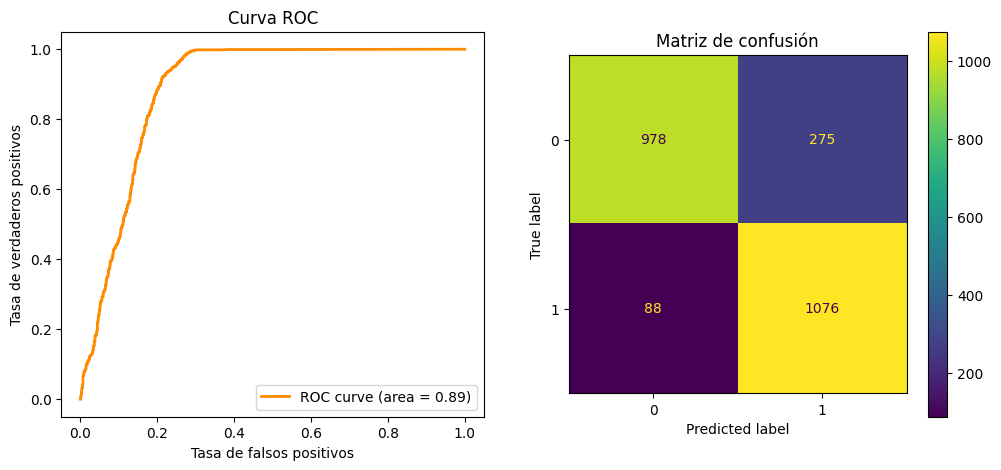

In [ ]:
model_RFC = RandomForestClassifier(random_state=42, class_weight='balanced', max_features=None)

param_grid_RFC = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    #'min_samples_split': [2, 5, 10],      # Mínimo número de muestras para dividir un nodo
    #'min_samples_leaf': [1, 2, 4],        # Mínimo número de muestras en una hoja
}

grid_RFC = GridSearchCV(model_RFC, param_grid_RFC, cv=5, scoring='f1', n_jobs=-1)
grid_RFC.fit(X_train, y_train)

print("-> RandomForestClassifier:", grid_RFC.best_params_)
print("-> Mejor score f1 (precisión y recall):", grid_RFC.best_score_)

best_RFC = grid_RFC.best_estimator_

y_pred_RFC = best_RFC.predict(X_test)

mse_RFC = mean_squared_error(y_test, y_pred_RFC)
mae_RFC = mean_absolute_error(y_test, y_pred_RFC)
f1_RFC = f1_score(y_test, y_pred_RFC)     # precisión y recall
accuracy_RFC = accuracy_score(y_test, y_pred_RFC)

print(f'MSE: {mse_RFC}')
print(f'MAE: {mae_RFC}')
print(f'F1 score: {f1_RFC}')
print("Accuracy:", accuracy_score(y_test, y_pred_RFC), '\n')

cm_RFC = confusion_matrix(y_test, y_pred_RFC)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("Curva ROC")
fpr, tpr, thresholds = roc_curve(y_test, best_RFC.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
axes[0].set_xlabel('Tasa de falsos positivos')
axes[0].set_ylabel('Tasa de verdaderos positivos')
axes[0].legend()
axes[0].grid(False)

axes[1].set_title("Matriz de confusión")
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_RFC)
disp.plot(ax=axes[1])
axes[1].grid(False)

### Modelo de gradiente descendente

In [ ]:
model_GBC = GradientBoostingClassifier(random_state=42)

param_grid_GBC = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 1],
    'subsample': [0.5, 0.8, 1.0],   # Fracción de muestras para entrenar cada árbol (boostrap sin reemplazo). Reduce sobreajuste.
    'max_depth': [3, 4, 5],         # Profundidad máxima de cada árbol. Controla complejidad y sobreajuste.
    #'criterion': ['friedman_mse', 'squared_error'],     # Función para medir la calidad del split
}

grid_GBC = GridSearchCV(model_GBC, param_grid_GBC, cv=5, scoring='f1', n_jobs=-1)
grid_GBC.fit(X_train, y_train)

print("-> GradientBoostingClassifier:", grid_GBC.best_params_)
print("-> Mejor score f1 (precisión y recall):", grid_GBC.best_score_)

best_GBC = grid_GBC.best_estimator_

y_pred_GBC = best_GBC.predict(X_test)

mse_GBC = mean_squared_error(y_test, y_pred_GBC)
mae_GBC = mean_absolute_error(y_test, y_pred_GBC)
f1_GBC = f1_score(y_test, y_pred_GBC)     # precisión y recall
accuracy_GBC = accuracy_score(y_test, y_pred_GBC)

print(f'MSE: {mse_GBC}')
print(f'MAE: {mae_GBC}')
print(f'F1 score: {f1_GBC}')
print("Accuracy:", accuracy_score(y_test, y_pred_GBC), '\n')

cm_GBC = metrics.confusion_matrix(y_test, y_pred_GBC)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("Curva ROC")
fpr, tpr, thresholds = roc_curve(y_test, best_GBC.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
axes[0].set_xlabel('Tasa de falsos positivos')
axes[0].set_ylabel('Tasa de verdaderos positivos')
axes[0].legend()
axes[0].grid(False)

axes[1].set_title("Matriz de confusión")
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_GBC)
disp.plot(ax=axes[1])
axes[1].grid(False)

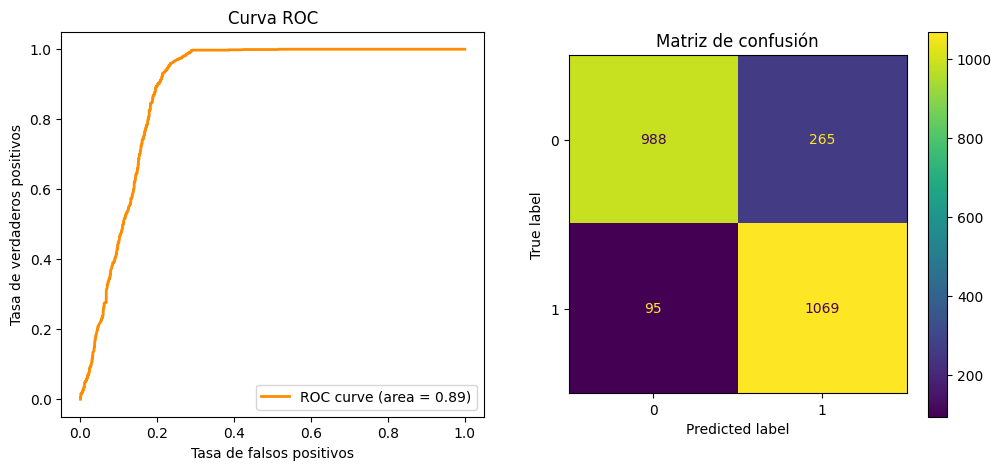

In [ ]:
cm_GBC = metrics.confusion_matrix(y_test, y_pred_GBC)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("Curva ROC")
fpr, tpr, thresholds = roc_curve(y_test, best_GBC.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
axes[0].set_xlabel('Tasa de falsos positivos')
axes[0].set_ylabel('Tasa de verdaderos positivos')
axes[0].legend()
axes[0].grid(False)

axes[1].set_title("Matriz de confusión")
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_GBC)
disp.plot(ax=axes[1])
axes[1].grid(False)

### Modelo de XGBoost

-> XGBClassifier: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100, 'reg_alpha': 0.1, 'reg_lambda': 0.1, 'subsample': 1.0}
-> Mejor score f1 (precisión y recall): 0.8522386634233887
MSE: 0.15018618121638394
MAE: 0.15018618121638394
F1 score: 0.8555511341026661
Accuracy: 0.8498138187836161 



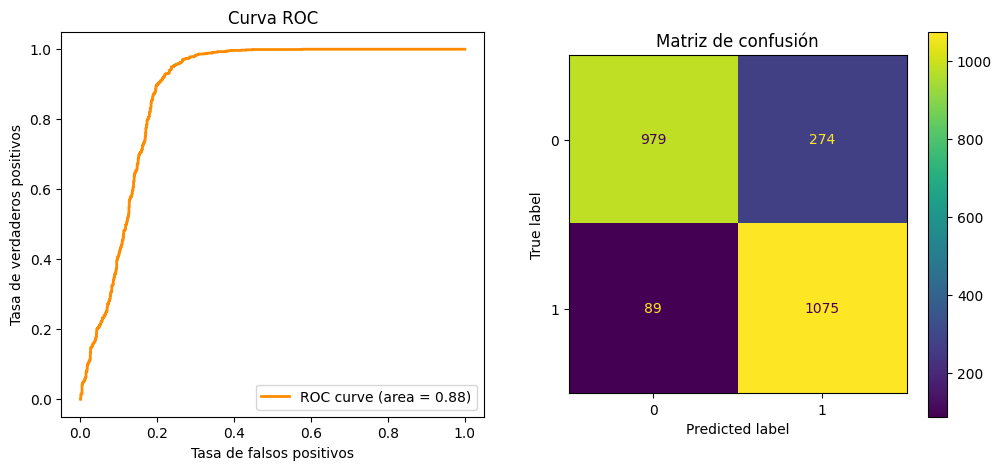

In [ ]:
Nneg, Npos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = Nneg/Npos      # Sirve para compensar el desbalanceo de clases

model_XGBC = xgb.XGBClassifier(eval_metric='logloss', scale_pos_weight=scale_pos_weight)

param_grid_XGBC = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 1],
    'max_depth': [3, 5, 7],
    'subsample': [0.5, 0.8, 1.0],     # Fracción de muestras usadas para entrenar cada árbol. Reduce sobreajuste introduciendo aleatoriedad.
    'reg_alpha': [0, 0.01, 0.1],      # Regularización L1 (Lasso)
    'reg_lambda': [0.01, 0.05, 0.1]   # Regularización L2 (Ridge)

}

grid_XGBC = GridSearchCV(model_XGBC, param_grid_XGBC, cv=5, scoring='f1', n_jobs=-1)
grid_XGBC.fit(X_train, y_train)

print("-> XGBClassifier:", grid_XGBC.best_params_)
print("-> Mejor score f1 (precisión y recall):", grid_XGBC.best_score_)

best_XGBC = grid_XGBC.best_estimator_

y_pred_XGBC = best_XGBC.predict(X_test)

mse_XGBC = mean_squared_error(y_test, y_pred_XGBC)
mae_XGBC = mean_absolute_error(y_test, y_pred_XGBC)
f1_XGBC = f1_score(y_test, y_pred_XGBC)     # precisión y recall
accuracy_XGBC = accuracy_score(y_test, y_pred_XGBC)

print(f'MSE: {mse_XGBC}')
print(f'MAE: {mae_XGBC}')
print(f'F1 score: {f1_XGBC}')
print("Accuracy:", accuracy_score(y_test, y_pred_XGBC), '\n')

cm_XGBC = metrics.confusion_matrix(y_test, y_pred_XGBC)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("Curva ROC")
fpr, tpr, thresholds = roc_curve(y_test, best_XGBC.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
axes[0].set_xlabel('Tasa de falsos positivos')
axes[0].set_ylabel('Tasa de verdaderos positivos')
axes[0].legend()
axes[0].grid(False)

axes[1].set_title("Matriz de confusión")
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_XGBC)
disp.plot(ax=axes[1])
axes[1].grid(False)

### Modelo de Lightgbm

[LightGBM] [Info] Number of positive: 4581, number of negative: 5083
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001616 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1160
[LightGBM] [Info] Number of data points in the train set: 9664, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.474027 -> initscore=-0.103984
[LightGBM] [Info] Start training from score -0.103984
-> LGBMClassifier: {'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 20, 'reg_alpha': 0, 'reg_lambda': 0.05, 'subsample': 0.1}
-> Mejor score f1 (precisión y recall): 0.859973290138565
MSE: 0.1439801406702524
MAE: 0.1439801406702524
F1 score: 0.8628841607565012
Accuracy: 0.8560198593297477 



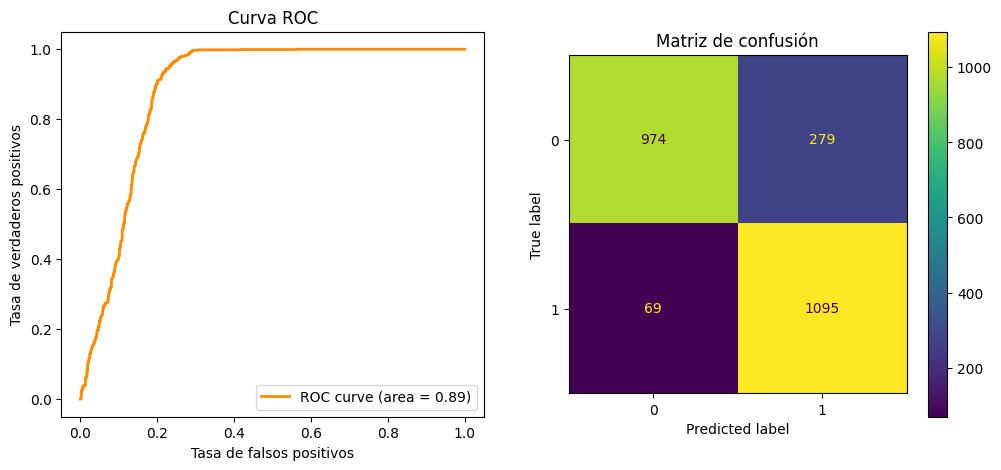

In [ ]:
model_LGBM = lgb.LGBMClassifier(scale_pos_weight=scale_pos_weight)

param_grid_LGBM = {
    'num_leaves': [10, 20],         # Número máximo de hojas en cada árbol
    'learning_rate': [0.01, 0.05, 1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.1, 0.2, 0.5],    # Fracción de muestras usadas para entrenar cada árbol. Reduce sobreajuste introduciendo aleatoriedad.
    'reg_alpha': [0, 0.01, 0.1],          # Regularización L1 (Lasso)
    'reg_lambda': [0.005, 0.01, 0.05]     # Regularización L2 (Ridge)
}

grid_LGBM = GridSearchCV(model_LGBM, param_grid_LGBM, cv=5, scoring='f1', n_jobs=-1)
grid_LGBM.fit(X_train, y_train)

print("-> LGBMClassifier:", grid_LGBM.best_params_)
print("-> Mejor score f1 (precisión y recall):", grid_LGBM.best_score_)

best_LGBM = grid_LGBM.best_estimator_

y_pred_LGBM = best_LGBM.predict(X_test)

mse_LGBM = mean_squared_error(y_test, y_pred_LGBM)
mae_LGBM = mean_absolute_error(y_test, y_pred_LGBM)
f1_LGBM = f1_score(y_test, y_pred_LGBM)     # precisión y recall
accuracy_LGBM = accuracy_score(y_test, y_pred_LGBM)

print(f'MSE: {mse_LGBM}')
print(f'MAE: {mae_LGBM}')
print(f'F1 score: {f1_LGBM}')
print("Accuracy:", accuracy_score(y_test, y_pred_LGBM), '\n')

cm_LGBM = metrics.confusion_matrix(y_test, y_pred_LGBM)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("Curva ROC")
fpr, tpr, thresholds = roc_curve(y_test, best_LGBM.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
axes[0].set_xlabel('Tasa de falsos positivos')
axes[0].set_ylabel('Tasa de verdaderos positivos')
axes[0].legend()
axes[0].grid(False)

axes[1].set_title("Matriz de confusión")
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_LGBM)
disp.plot(ax=axes[1])
axes[1].grid(False)

### Modelo de máquinas vectoriales

-> SVC: {'C': 0.1, 'kernel': 'linear'}
-> Mejor score f1 (precisión y recall): 0.8282430584700267
MSE: 0.18038891187422423
MAE: 0.18038891187422423
F1 score: 0.8299531981279251
Accuracy: 0.8196110881257758 



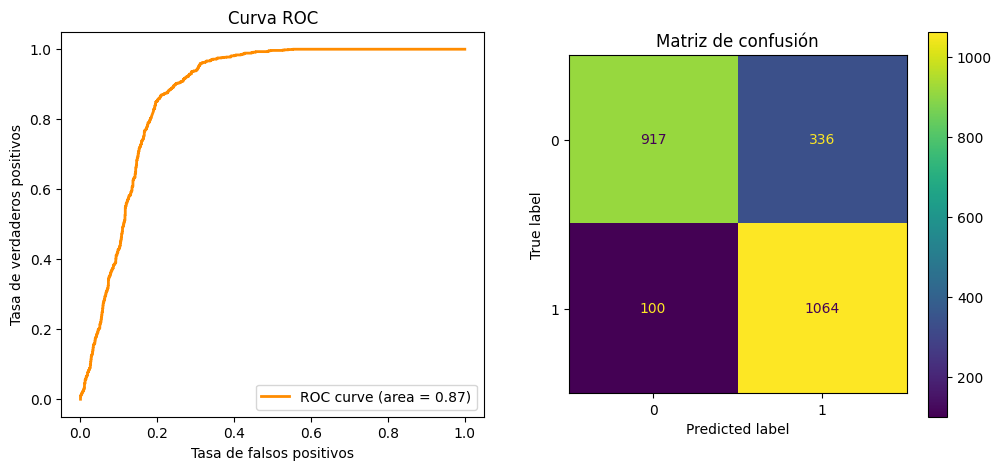

In [ ]:
model_SVC = SVC(class_weight='balanced', probability=True)

param_grid_SVC = {
    'C': [0.01, 0.1, 1.0, 10, 15],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']
}

grid_SVC = GridSearchCV(model_SVC, param_grid_SVC, cv=5, scoring='f1', n_jobs=-1)
grid_SVC.fit(X_train, y_train)

print("-> SVC:", grid_SVC.best_params_)
print("-> Mejor score f1 (precisión y recall):", grid_SVC.best_score_)

best_SVC = grid_SVC.best_estimator_

y_pred_SVC = best_SVC.predict(X_test)

mse_SVC = mean_squared_error(y_test, y_pred_SVC)
mae_SVC = mean_absolute_error(y_test, y_pred_SVC)
f1_SVC = f1_score(y_test, y_pred_SVC)     # precisión y recall
accuracy_SVC = accuracy_score(y_test, y_pred_SVC)

print(f'MSE: {mse_SVC}')
print(f'MAE: {mae_SVC}')
print(f'F1 score: {f1_SVC}')
print("Accuracy:", accuracy_score(y_test, y_pred_SVC), '\n')

cm_SVC = metrics.confusion_matrix(y_test, y_pred_SVC)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("Curva ROC")
fpr, tpr, thresholds = roc_curve(y_test, best_SVC.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
axes[0].set_xlabel('Tasa de falsos positivos')
axes[0].set_ylabel('Tasa de verdaderos positivos')
axes[0].legend()
axes[0].grid(False)

axes[1].set_title("Matriz de confusión")
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_SVC)
disp.plot(ax=axes[1])
axes[1].grid(False)

plt.show()

### Comparación de los modelos de clasificación

In [ ]:
compare = pd.DataFrame({
    'Modelo': ['LogisticRegression', 'DecisionTree', 'RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM', 'SVC'],
    'MSE': [mse_LG, mse_DTC, mse_RFC, mse_GBC, mse_XGBC, mse_LGBM, mse_SVC],
    'MAE': [mae_LG, mae_DTC, mae_RFC, mae_GBC, mae_XGBC, mae_LGBM, mae_SVC],
    'F1': [f1_LG, f1_DTC, f1_RFC, f1_GBC, f1_XGBC, f1_LGBM, f1_SVC],
    'Accuracy': [accuracy_LG, accuracy_DTC, accuracy_RFC, accuracy_GBC, accuracy_XGBC, accuracy_LGBM, accuracy_SVC]
}).set_index('Modelo')

compare

,MSE,MAE,F1,Accuracy
Modelo,,,,
LogisticRegression,0.179975,0.179975,0.816068,0.820025
DecisionTree,0.158875,0.158875,0.844282,0.841125
RandomForest,0.150186,0.150186,0.855666,0.849814
GradientBoosting,0.148945,0.148945,0.855885,0.851055
XGBoost,0.150186,0.150186,0.855551,0.849814
LightGBM,0.143980,0.143980,0.862884,0.856020
SVC,0.180389,0.180389,0.829953,0.819611


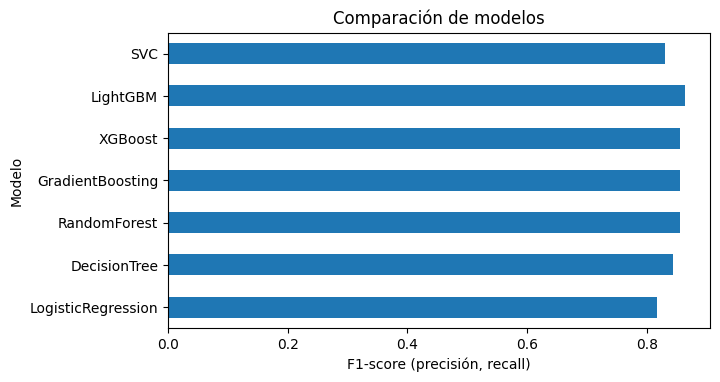

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.84))
compare['F1'].plot(kind='barh', ax=ax)
ax.set_xlabel('F1-score (precisión, recall)')
ax.set_ylabel('Modelo')
ax.set_title('Comparación de modelos');

In [ ]:
cm_LG = confusion_matrix(y_test, y_pred_LG)
cm_DTC = confusion_matrix(y_test, y_pred_DTC)
cm_RFC = confusion_matrix(y_test, y_pred_RFC)
cm_GBC = confusion_matrix(y_test, y_pred_GBC)
cm_XGBC = confusion_matrix(y_test, y_pred_XGBC)
cm_LGBM = confusion_matrix(y_test, y_pred_LGBM)
cm_SVC = confusion_matrix(y_test, y_pred_SVC)

confusion_matrices = {
    'LogisticRegression': cm_LG,
    'DecisionTree': cm_DTC,
    'RandomForest': cm_RFC,
    'GradientBoosting': cm_GBC,
    'XGBoost': cm_XGBC,
    'LightGBM': cm_LGBM,
    'SVC': cm_SVC
}

cm_data = []

for model_name, cm in confusion_matrices.items():
  tn, fp, fn, tp = cm.ravel()
  cm_data.append({
      'Modelo': model_name,
      'True Negatives (TN)': tn,
      'False Positives (FP)': fp,
      'False Negatives (FN)': fn,
      'True Positives (TP)': tp
  })

cm_df = pd.DataFrame(cm_data).set_index('Modelo')
cm_df

,True Negatives (TN),False Positives (FP),False Negatives (FN),True Positives (TP)
Modelo,,,,
LogisticRegression,1017,236,199,965
DecisionTree,992,261,123,1041
RandomForest,978,275,88,1076
GradientBoosting,988,265,95,1069
XGBoost,979,274,89,1075
LightGBM,974,279,69,1095
SVC,917,336,100,1064
